In [136]:
import sys
sys.executable

'/home/gianl/miniconda3/envs/vm2/bin/python'

In [137]:
import os
os.getcwd()


'/home/gianl/Dokumente/projekte/VM2-RC-Modell-ui/notebooks'

In [138]:
import os, sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
print("PROJECT_ROOT =", PROJECT_ROOT)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

PROJECT_ROOT = /home/gianl/Dokumente/projekte/VM2-RC-Modell-ui


In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from pathlib import Path

from core.bootstrap import create_facade # imports the connection to the midlayer


In [140]:
PROJECT_ID = "rc-model-validation"
VARIANT_ID = "Val"
facade_Val = create_facade(PROJECT_ID, VARIANT_ID)

facade_Val.run_simulation(PROJECT_ID, VARIANT_ID)

Simulation finished.


RunReport(ok=True, run_id='latest', message='Simulation for project rc-model-validation and variant Val completed successfully.')

In [141]:
# load results
df_res_py = facade_Val._result.load_raw()
df_res_py = df_res_py.drop(columns=["temperature_outdoor_air"], axis=1)
df_res_py.head(5)

,temperature_air_room,temperature_in_glazing_north,temperature_in_glazing_east,temperature_in_glazing_south,temperature_in_glazing_west,temperature_out_glazing_north,temperature_out_glazing_east,temperature_out_glazing_south,temperature_out_glazing_west,temperature_in_frame_north,...,temperature_wall_s_4,temperature_wall_w_4,temperature_roof_4,temperature_floor_4,temperature_int_wall_4,temperature_int_ceiling_4,output_heating_power,output_cooling_power,output_lighting_electricity,output_equipment_electricity
datetime,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,20.999932,19.038826,19.038826,19.038826,19.038826,-0.704811,-0.704811,-0.704811,-0.704811,14.425267,...,-1.195237,-1.196421,-1.321316,11.751779,21.140147,21.145817,2.054434e+07,0.0,-2.273737e-13,753.12
2019-01-01 01:00:00,20.999935,19.120319,19.120319,19.120319,19.120319,0.262085,0.262085,0.262085,0.262085,14.713655,...,-0.188267,-0.189389,-0.292706,11.749165,21.088623,21.135429,1.909607e+07,0.0,-2.273737e-13,753.12
2019-01-01 02:00:00,20.999938,19.198757,19.198757,19.198757,19.198757,1.173925,1.173925,1.173925,1.173925,14.986837,...,0.743094,0.742029,0.643982,11.746535,21.045612,21.122768,1.825127e+07,0.0,-2.273737e-13,753.12
2019-01-01 03:00:00,20.999941,19.268436,19.268436,19.268436,19.268436,1.975559,1.975559,1.975559,1.975559,15.227554,...,1.562758,1.561747,1.468941,11.743895,21.010012,21.108881,1.748305e+07,0.0,-2.273737e-13,753.12
2019-01-01 04:00:00,20.999942,19.310291,19.310291,19.310291,19.310291,2.462902,2.462902,2.462902,2.462902,15.373508,...,2.064682,2.063722,1.977196,11.741246,20.980677,21.094512,1.691385e+07,0.0,-2.273737e-13,753.12


# load matlab result

In [142]:
# path to matlab results
mat_path = Path(PROJECT_ROOT) / 'projects' / 'rc-model-validation' / 'mat-reference' / 'matlab_ref_results.mat'

# load matlab results
mat_data = loadmat(mat_path, squeeze_me=True)

# Extract relevant output data from MATLAB structure
Q_c_ref = mat_data['output_cooling_power']
Q_h_ref = mat_data['output_heating_power']
El_ref = mat_data['output_lighting_electricity']
Eq_ref = mat_data['output_equipment_electricity']

# Create DataFrame for MATLAB outputs
df_outputs = pd.DataFrame({
    'output_heating_power': Q_h_ref,
    'output_cooling_power': Q_c_ref,
    'output_lighting_electricity': El_ref,
    'output_equipment_electricity': Eq_ref
})


try:
    row_names_all = df_res_py.columns.tolist()
    row_names = row_names_all[:-4]  # Exclude first and last four columns
except NameError:
    print("df_res_py is not defined.")
    
temp_mat_array = mat_data['output_temperatures']
num_rows_mat = temp_mat_array.shape[1]

if len(row_names) != num_rows_mat:
    print("Warning: Number of row names does not match number of rows in the MATLAB data.")
    print(f"Number of row names: {len(row_names)}, Number of rows in MATLAB data: {num_rows_mat}")
else:
    df_temp_outputs = pd.DataFrame(
        data=temp_mat_array,
        columns=row_names
    )

df_res_mat = pd.concat([df_temp_outputs, df_outputs], axis=1)
df_res_mat.head()


,temperature_air_room,temperature_in_glazing_north,temperature_in_glazing_east,temperature_in_glazing_south,temperature_in_glazing_west,temperature_out_glazing_north,temperature_out_glazing_east,temperature_out_glazing_south,temperature_out_glazing_west,temperature_in_frame_north,...,temperature_wall_s_4,temperature_wall_w_4,temperature_roof_4,temperature_floor_4,temperature_int_wall_4,temperature_int_ceiling_4,output_heating_power,output_cooling_power,output_lighting_electricity,output_equipment_electricity
0,20.905853,18.793906,18.793906,18.793906,18.793906,-0.713638,-0.713638,-0.713638,-0.713638,13.990463,...,-1.199977,-1.201227,-1.324237,11.744259,20.730805,20.772433,21063.686547,0.0,-2.273737e-13,753.12
1,20.908765,18.886626,18.886626,18.886626,18.886626,0.253663,0.253663,0.253663,0.253663,14.298536,...,-0.192939,-0.194127,-0.295613,11.741659,20.719788,20.765526,19995.501184,0.0,-2.273737e-13,753.12
2,20.911558,18.974430,18.974430,18.974430,18.974430,1.165840,1.165840,1.165840,1.165840,14.589330,...,0.738508,0.737377,0.641098,11.739059,20.712807,20.758921,19381.661872,0.0,-2.273737e-13,753.12
3,20.914053,19.051837,19.051837,19.051837,19.051837,1.967752,1.967752,1.967752,1.967752,14.845135,...,1.558268,1.557192,1.466090,11.736458,20.708659,20.752766,18813.129875,0.0,-2.273737e-13,753.12
4,20.915564,19.098664,19.098664,19.098664,19.098664,2.455275,2.455275,2.455275,2.455275,15.000477,...,2.060295,2.059270,1.974384,11.733857,20.706447,20.747101,18389.275320,0.0,-2.273737e-13,753.12


In [143]:
# path to ida results
mat_path = Path(PROJECT_ROOT) / 'projects' / 'rc-model-validation' / 'mat-reference' / 'ida_results_ver2.mat'

# load matlab results
ida_data = loadmat(mat_path, squeeze_me=True)
df_res_ida = pd.DataFrame({
    "temperature_air_room": ida_data['ida_air_temp'],
    "output_heating_power": ida_data['ida_heating_power'],
    "output_cooling_power": ida_data['ida_cooling_power'],
})
df_res_ida.head()

,temperature_air_room,output_heating_power,output_cooling_power
0,21.01,21031.5,0.0
1,21.00,20130.4,0.0
2,21.00,19462.9,0.0
3,21.00,18866.0,0.0
4,21.00,18468.0,0.0


# Compare Python and Matlab code

In [144]:
df_res_mat.index = df_res_py.index

df_diff = df_res_py.subtract(df_res_mat, fill_value=0)
df_diff.head()

,temperature_air_room,temperature_in_glazing_north,temperature_in_glazing_east,temperature_in_glazing_south,temperature_in_glazing_west,temperature_out_glazing_north,temperature_out_glazing_east,temperature_out_glazing_south,temperature_out_glazing_west,temperature_in_frame_north,...,temperature_wall_s_4,temperature_wall_w_4,temperature_roof_4,temperature_floor_4,temperature_int_wall_4,temperature_int_ceiling_4,output_heating_power,output_cooling_power,output_lighting_electricity,output_equipment_electricity
datetime,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,0.094080,0.244920,0.244920,0.244920,0.244920,0.008827,0.008827,0.008827,0.008827,0.434804,...,0.004740,0.004806,0.002921,0.007521,0.409343,0.373384,2.052328e+07,0.0,0.0,0.0
2019-01-01 01:00:00,0.091170,0.233693,0.233693,0.233693,0.233693,0.008423,0.008423,0.008423,0.008423,0.415119,...,0.004672,0.004738,0.002908,0.007505,0.368835,0.369903,1.907607e+07,0.0,0.0,0.0
2019-01-01 02:00:00,0.088380,0.224327,0.224327,0.224327,0.224327,0.008085,0.008085,0.008085,0.008085,0.397507,...,0.004586,0.004652,0.002883,0.007476,0.332806,0.363847,1.823189e+07,0.0,0.0,0.0
2019-01-01 03:00:00,0.085888,0.216599,0.216599,0.216599,0.216599,0.007806,0.007806,0.007806,0.007806,0.382419,...,0.004489,0.004555,0.002851,0.007437,0.301353,0.356115,1.746424e+07,0.0,0.0,0.0
2019-01-01 04:00:00,0.084378,0.211627,0.211627,0.211627,0.211627,0.007627,0.007627,0.007627,0.007627,0.373031,...,0.004387,0.004453,0.002812,0.007389,0.274229,0.347411,1.689546e+07,0.0,0.0,0.0


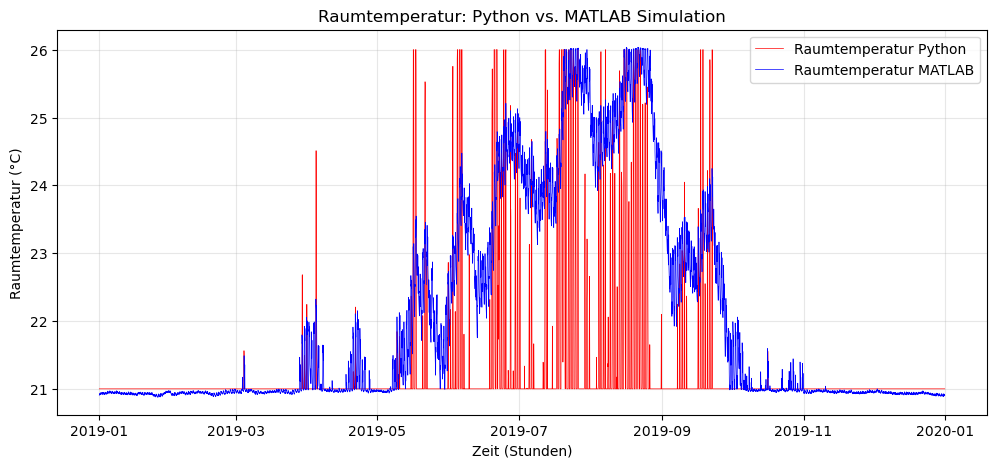

In [145]:
x = df_res_py.index
y1 = df_res_py["temperature_air_room"]
y2 = df_res_mat["temperature_air_room"]


fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x, y1, label='Raumtemperatur Python', color='red', linewidth=0.5)
ax.plot(x, y2, label='Raumtemperatur MATLAB', color='blue', linewidth=0.5)
ax.set_title('Raumtemperatur: Python vs. MATLAB Simulation')
ax.set_xlabel('Zeit (Stunden)')
ax.set_ylabel('Raumtemperatur (°C)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()



Maximum Absolute Error $E_{max}$:

In [146]:
max_abs_err_temp_room= np.max(np.abs(df_diff["temperature_air_room"]))
max_abs_err_heating_power= np.max(np.abs(df_diff["output_heating_power"]))
max_abs_err_cooling_power= np.max(np.abs(df_diff["output_cooling_power"]))
max_abs_err_lighting_electricity= np.max(np.abs(df_diff["output_lighting_electricity"]))
max_abs_err_equipment_electricity= np.max(np.abs(df_diff["output_equipment_electricity"]))
print(f"Max absolute error in room temperature: {max_abs_err_temp_room:.4e} °C")
print(f"Max absolute error in heating power: {max_abs_err_heating_power:.4e} W")
print(f"Max absolute error in cooling power: {max_abs_err_cooling_power:.4e} W")
print(f"Max absolute error in lighting electricity: {max_abs_err_lighting_electricity:.4e} W")
print(f"Max absolute error in equipment electricity: {max_abs_err_equipment_electricity:.4e} W")

Max absolute error in room temperature: 5.0131e+00 °C
Max absolute error in heating power: 2.6795e+07 W
Max absolute error in cooling power: 7.4908e+06 W
Max absolute error in lighting electricity: 2.4448e+04 W
Max absolute error in equipment electricity: 6.7781e+03 W


Root Mean Square Error $E_{RMSE}$:

In [147]:
rmse_temp_room= np.sqrt(np.mean(df_diff["temperature_air_room"]**2))
rmse_heating_power= np.sqrt(np.mean(df_diff["output_heating_power"]**2))
rmse_cooling_power= np.sqrt(np.mean(df_diff["output_cooling_power"]**2))
rmse_lighting_electricity= np.sqrt(np.mean(df_diff["output_lighting_electricity"]**2))
rmse_equipment_electricity= np.sqrt(np.mean(df_diff["output_equipment_electricity"]**2))
print(f"RMSE in room temperature: {rmse_temp_room:.4e} °C")
print(f"RMSE in heating power: {rmse_heating_power:.4e} W")
print(f"RMSE in cooling power: {rmse_cooling_power:.4e} W")
print(f"RMSE in lighting electricity: {rmse_lighting_electricity:.4e} W")
print(f"RMSE in equipment electricity: {rmse_equipment_electricity:.4e} W")

RMSE in room temperature: 1.6131e+00 °C
RMSE in heating power: 1.1218e+07 W
RMSE in cooling power: 3.9914e+05 W
RMSE in lighting electricity: 8.6092e+03 W
RMSE in equipment electricity: 1.4005e+03 W


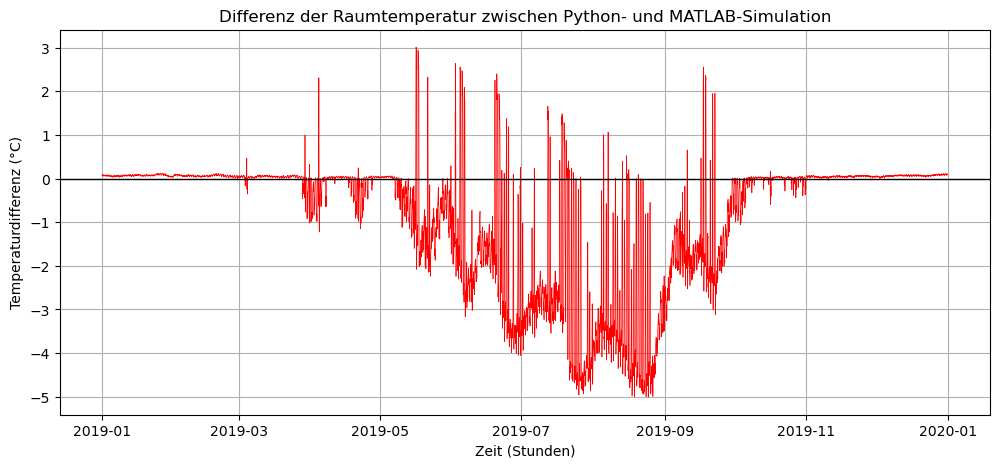

In [148]:
plt.figure(figsize=(12, 5))
plt.plot(df_res_py.index, df_diff["temperature_air_room"], label='Differenz (Python - MATLAB)', color='red', linewidth=0.5)
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.title('Differenz der Raumtemperatur zwischen Python- und MATLAB-Simulation')
plt.xlabel('Zeit (Stunden)')
plt.ylabel('Temperaturdifferenz (°C)')
plt.grid(True)
plt.show()


# Compare Python and IDA ICE

In [149]:
df_res_ida.index = df_res_py.index
df_res_py= df_res_py[df_res_ida.columns]

df_diff_ida = df_res_py.subtract(df_res_ida, fill_value=0)
df_diff.head()

,temperature_air_room,temperature_in_glazing_north,temperature_in_glazing_east,temperature_in_glazing_south,temperature_in_glazing_west,temperature_out_glazing_north,temperature_out_glazing_east,temperature_out_glazing_south,temperature_out_glazing_west,temperature_in_frame_north,...,temperature_wall_s_4,temperature_wall_w_4,temperature_roof_4,temperature_floor_4,temperature_int_wall_4,temperature_int_ceiling_4,output_heating_power,output_cooling_power,output_lighting_electricity,output_equipment_electricity
datetime,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,0.094080,0.244920,0.244920,0.244920,0.244920,0.008827,0.008827,0.008827,0.008827,0.434804,...,0.004740,0.004806,0.002921,0.007521,0.409343,0.373384,2.052328e+07,0.0,0.0,0.0
2019-01-01 01:00:00,0.091170,0.233693,0.233693,0.233693,0.233693,0.008423,0.008423,0.008423,0.008423,0.415119,...,0.004672,0.004738,0.002908,0.007505,0.368835,0.369903,1.907607e+07,0.0,0.0,0.0
2019-01-01 02:00:00,0.088380,0.224327,0.224327,0.224327,0.224327,0.008085,0.008085,0.008085,0.008085,0.397507,...,0.004586,0.004652,0.002883,0.007476,0.332806,0.363847,1.823189e+07,0.0,0.0,0.0
2019-01-01 03:00:00,0.085888,0.216599,0.216599,0.216599,0.216599,0.007806,0.007806,0.007806,0.007806,0.382419,...,0.004489,0.004555,0.002851,0.007437,0.301353,0.356115,1.746424e+07,0.0,0.0,0.0
2019-01-01 04:00:00,0.084378,0.211627,0.211627,0.211627,0.211627,0.007627,0.007627,0.007627,0.007627,0.373031,...,0.004387,0.004453,0.002812,0.007389,0.274229,0.347411,1.689546e+07,0.0,0.0,0.0


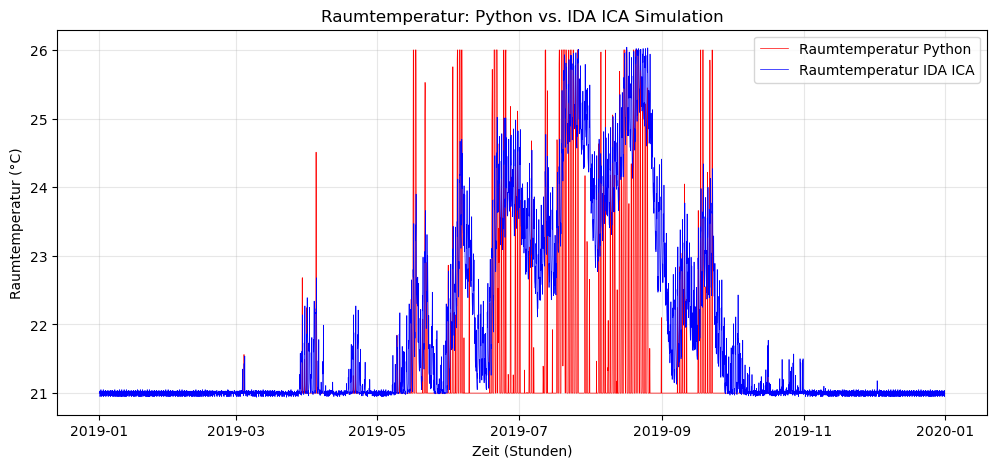

In [150]:
x = df_res_py.index
y1 = df_res_py["temperature_air_room"]
y2 = df_res_ida["temperature_air_room"]


fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x, y1, label='Raumtemperatur Python', color='red', linewidth=0.5)
ax.plot(x, y2, label='Raumtemperatur IDA ICA', color='blue', linewidth=0.5)
ax.set_title('Raumtemperatur: Python vs. IDA ICA Simulation')
ax.set_xlabel('Zeit (Stunden)')
ax.set_ylabel('Raumtemperatur (°C)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()



Maximum Absolute Error $E_{max}$:

In [151]:
max_abs_err_temp_room= np.max(np.abs(df_diff_ida["temperature_air_room"]))
max_abs_err_heating_power= np.max(np.abs(df_diff_ida["output_heating_power"]))
max_abs_err_cooling_power= np.max(np.abs(df_diff_ida["output_cooling_power"]))

print(f"Max absolute error in room temperature: {max_abs_err_temp_room:.4e} °C")
print(f"Max absolute error in heating power: {max_abs_err_heating_power:.4e} W")
print(f"Max absolute error in cooling power: {max_abs_err_cooling_power:.4e} W")


Max absolute error in room temperature: 4.9400e+00 °C
Max absolute error in heating power: 2.6794e+07 W
Max absolute error in cooling power: 7.4917e+06 W


Root Mean Square Error $E_{RMSE}$:

In [152]:
rmse_temp_room= np.sqrt(np.mean(df_diff_ida["temperature_air_room"]**2))
rmse_heating_power= np.sqrt(np.mean(df_diff_ida["output_heating_power"]**2))
rmse_cooling_power= np.sqrt(np.mean(df_diff_ida["output_cooling_power"]**2))
print(f"RMSE in room temperature: {rmse_temp_room:.4e} °C")
print(f"RMSE in heating power: {rmse_heating_power:.4e} W")
print(f"RMSE in cooling power: {rmse_cooling_power:.4e} W")


RMSE in room temperature: 1.2973e+00 °C
RMSE in heating power: 1.1217e+07 W
RMSE in cooling power: 3.9935e+05 W


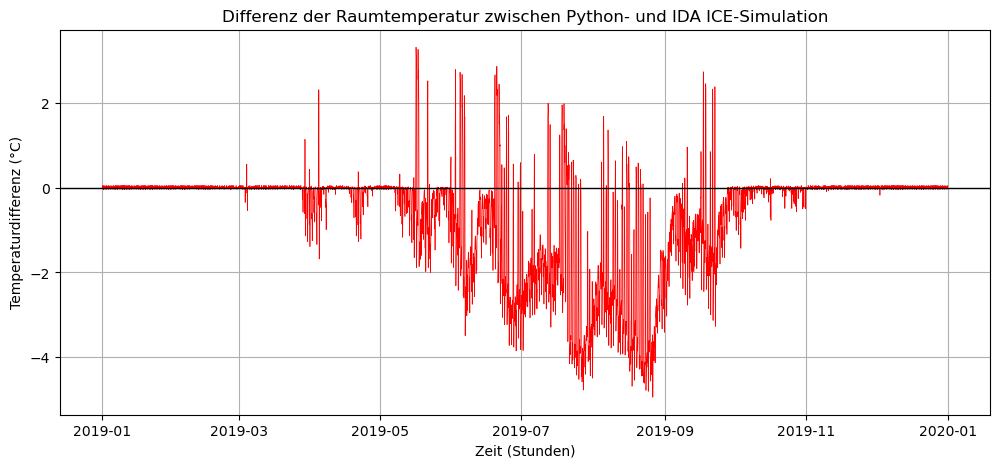

In [153]:
plt.figure(figsize=(12, 5))
plt.plot(df_res_py.index, df_diff_ida["temperature_air_room"], label='Differenz (Python - IDA ICE)', color='red', linewidth=0.5)
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.title('Differenz der Raumtemperatur zwischen Python- und IDA ICE-Simulation')
plt.xlabel('Zeit (Stunden)')
plt.ylabel('Temperaturdifferenz (°C)')
plt.grid(True)
plt.show()


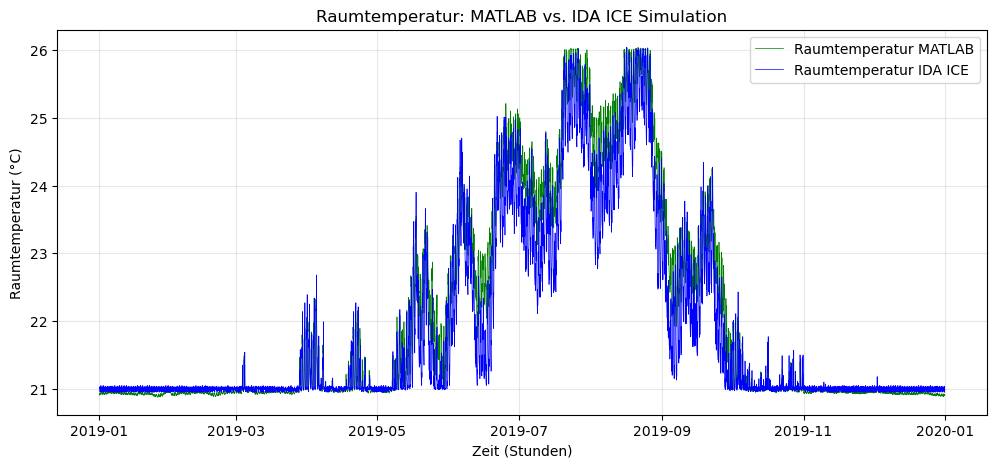

Max Fehler Raumtemperatur: 1.3528e+00 °C
Max Fehler Heizleistung:   9.3183e+03 W
Max Fehler Kühlleistung:   1.3574e+04 W
RMSE Raumtemperatur:       4.2839e-01 °C
RMSE Heizleistung:         1.4120e+03 W
RMSE Kühlleistung:         5.5324e+02 W


In [154]:
# Vergleich MATLAB vs. IDA ICE (analog zu oben)
df_res_mat_comp = df_res_mat[df_res_ida.columns]
df_res_mat_comp.index = df_res_ida.index

df_diff_mat_ida = df_res_mat_comp.subtract(df_res_ida, fill_value=0)

# Plot Raumtemperaturvergleich
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_res_ida.index, df_res_mat_comp["temperature_air_room"], label="Raumtemperatur MATLAB", color="green", linewidth=0.5)
ax.plot(df_res_ida.index, df_res_ida["temperature_air_room"], label="Raumtemperatur IDA ICE", color="blue", linewidth=0.5)
ax.set_title("Raumtemperatur: MATLAB vs. IDA ICE Simulation")
ax.set_xlabel("Zeit (Stunden)")
ax.set_ylabel("Raumtemperatur (°C)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Fehlerkennzahlen
max_abs_err_temp = np.max(np.abs(df_diff_mat_ida["temperature_air_room"]))
max_abs_err_heat = np.max(np.abs(df_diff_mat_ida["output_heating_power"]))
max_abs_err_cool = np.max(np.abs(df_diff_mat_ida["output_cooling_power"]))

rmse_temp = np.sqrt(np.mean(df_diff_mat_ida["temperature_air_room"]**2))
rmse_heat = np.sqrt(np.mean(df_diff_mat_ida["output_heating_power"]**2))
rmse_cool = np.sqrt(np.mean(df_diff_mat_ida["output_cooling_power"]**2))

print(f"Max Fehler Raumtemperatur: {max_abs_err_temp:.4e} °C")
print(f"Max Fehler Heizleistung:   {max_abs_err_heat:.4e} W")
print(f"Max Fehler Kühlleistung:   {max_abs_err_cool:.4e} W")
print(f"RMSE Raumtemperatur:       {rmse_temp:.4e} °C")
print(f"RMSE Heizleistung:         {rmse_heat:.4e} W")
print(f"RMSE Kühlleistung:         {rmse_cool:.4e} W")